**Part 1: Data Preparation and Exploration**
**1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.**
**2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.**
**3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\HP\Downloads\Timeseries\Timeseries\exchange_rate.csv",parse_dates=[0], index_col=0)
df

,Ex_rate
date,
01-01-1990 00:00,0.785500
02-01-1990 00:00,0.781800
03-01-1990 00:00,0.786700
04-01-1990 00:00,0.786000
05-01-1990 00:00,0.784900
...,...
06-10-2010 00:00,0.718494
07-10-2010 00:00,0.721839
08-10-2010 00:00,0.723197


In [2]:
df.index = pd.to_datetime(df.index, format='%d-%m-%Y %H:%M')
df

,Ex_rate
date,
1990-01-01,0.785500
1990-01-02,0.781800
1990-01-03,0.786700
1990-01-04,0.786000
1990-01-05,0.784900
...,...
2010-10-06,0.718494
2010-10-07,0.721839
2010-10-08,0.723197


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


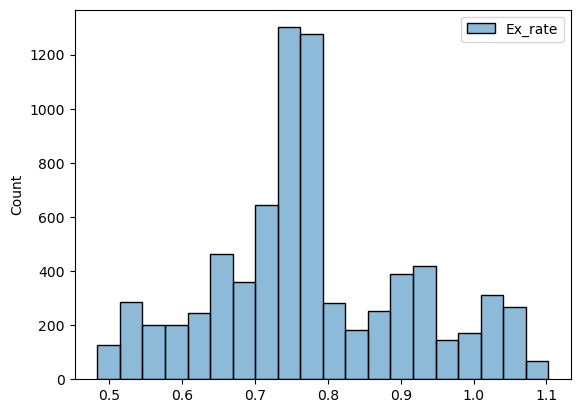

In [4]:
sns.histplot(data=df,bins=20)
plt.show()

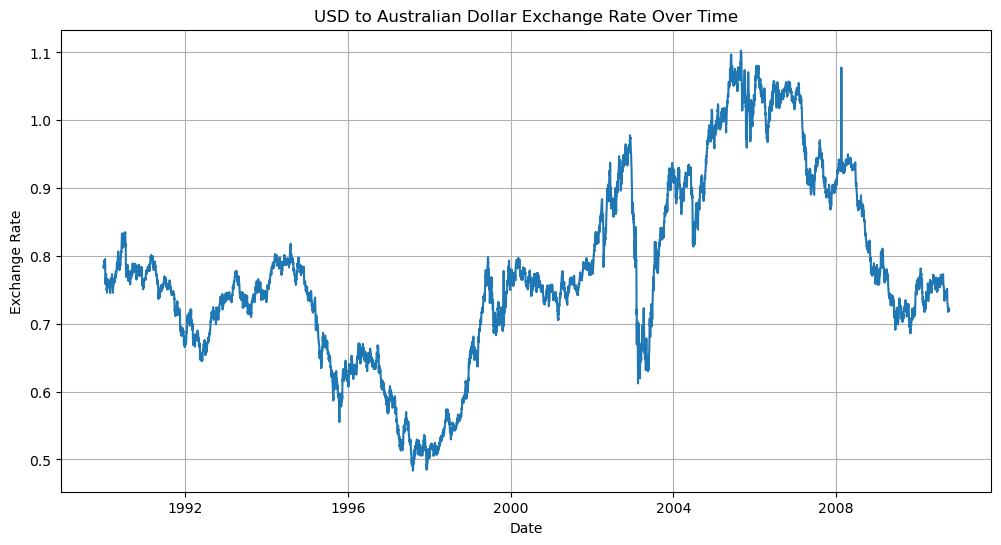

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df['Ex_rate'])
plt.title('USD to Australian Dollar Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True)
plt.show()

**Part 2: Model Building - ARIMA**
**1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.**
**2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.**
**3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.**

ADF Statistic: -1.6649941807381528
p-value: 0.4492327353597901


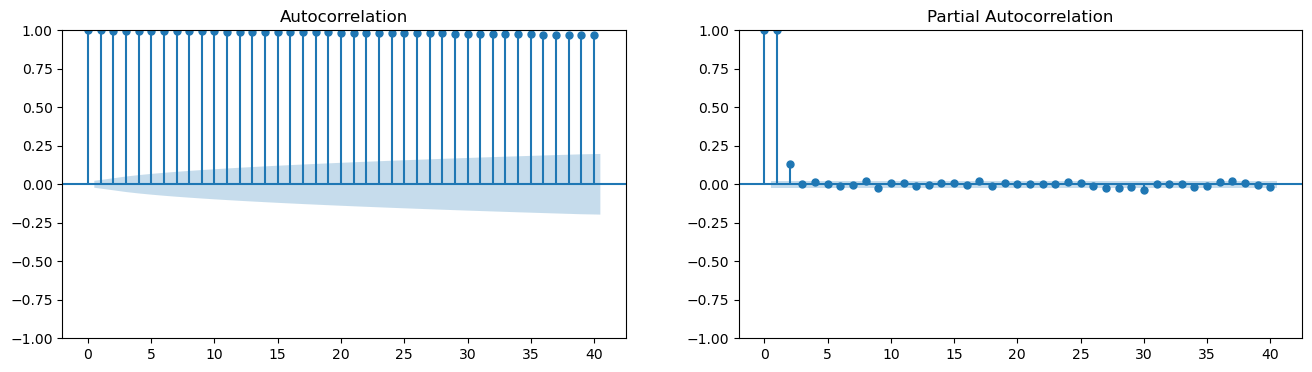

In [6]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Stationarity Check
result = adfuller(df['Ex_rate'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}') # If > 0.05, data needs differencing (d=1)

# 2. Plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['Ex_rate'], ax=ax1, lags=40)
plot_pacf(df['Ex_rate'], ax=ax2, lags=40)
plt.show()

In [7]:
# 1. Create a new "differenced" version of your data
# We use .dropna() because the first row will be NaN (there's no 'yesterday' for the first day)
df_diff = df.diff().dropna()

# 2. Run the ADF test again on the new data
from statsmodels.tsa.stattools import adfuller
result = adfuller(df_diff['Ex_rate'])

print(f'New p-value: {result[1]}')

New p-value: 0.0


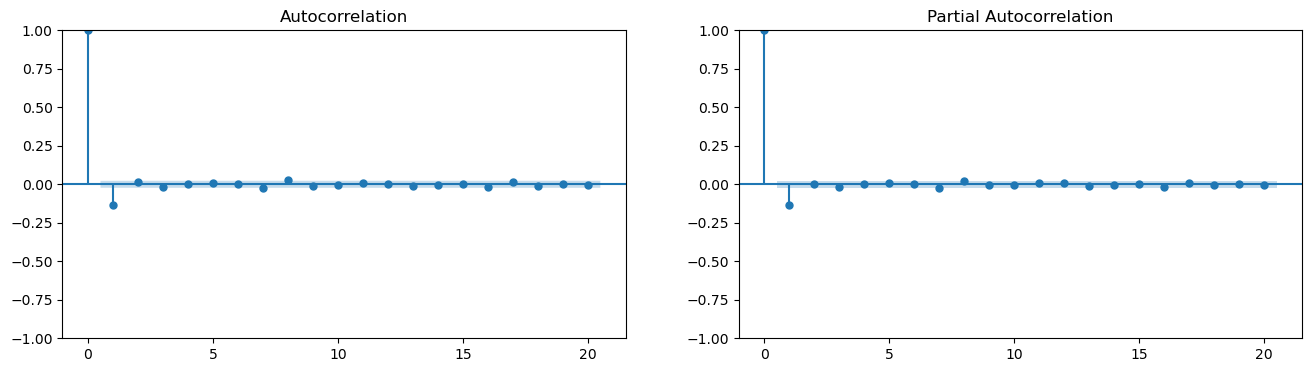

In [8]:
# Plotting on the DIFFERENCED data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_diff['Ex_rate'], ax=ax1, lags=20)
plot_pacf(df_diff['Ex_rate'], ax=ax2, lags=20)
plt.show()

In [9]:
from statsmodels.tsa.arima.model import ARIMA
# p=1, d=1, q=1
model = ARIMA(df['Ex_rate'], order=(1, 1, 1))
model_fit = model.fit()

# Look at the summary to see if the p-values for 'ar.L1' and 'ma.L1' are < 0.05
print(model_fit.summary())

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Wed, 29 Apr 2026   AIC                         -56102.322
Time:                        01:43:07   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

In [10]:
# Change the order to (1, 1, 0) to drop the MA component
model1 = ARIMA(df['Ex_rate'], order=(1, 1, 0)) 
model_fit1 = model1.fit()

# Check the new summary
print(model_fit1.summary())

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 0)   Log Likelihood               28054.159
Date:                Wed, 29 Apr 2026   AIC                         -56104.319
Time:                        01:43:08   BIC                         -56090.450
Sample:                    01-01-1990   HQIC                        -56099.559
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1314      0.002    -64.439      0.000      -0.135      -0.127
sigma2      3.595e-05   9.94e-08    361.720      0.000    3.58e-05    3.61e-05
Ljung-Box (L1) (Q):                   0.00   Jarque-

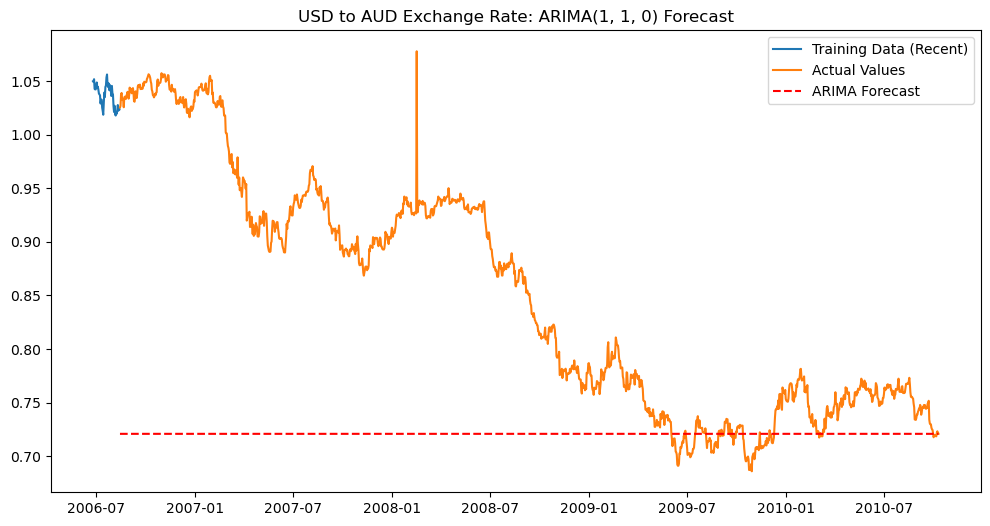

In [11]:

# Split data: 80% train, 20% test
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

arima_forecast = model_fit1.forecast(steps=len(test))

# Plotting Forecast vs Actual
plt.figure(figsize=(12, 6))
plt.plot(train.index[-50:], train['Ex_rate'][-50:], label='Training Data (Recent)')
plt.plot(test.index, test['Ex_rate'], label='Actual Values')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.title('USD to AUD Exchange Rate: ARIMA(1, 1, 0) Forecast')
plt.legend()
plt.show()

**4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.**

Starting forecast loop...
Forecast complete.


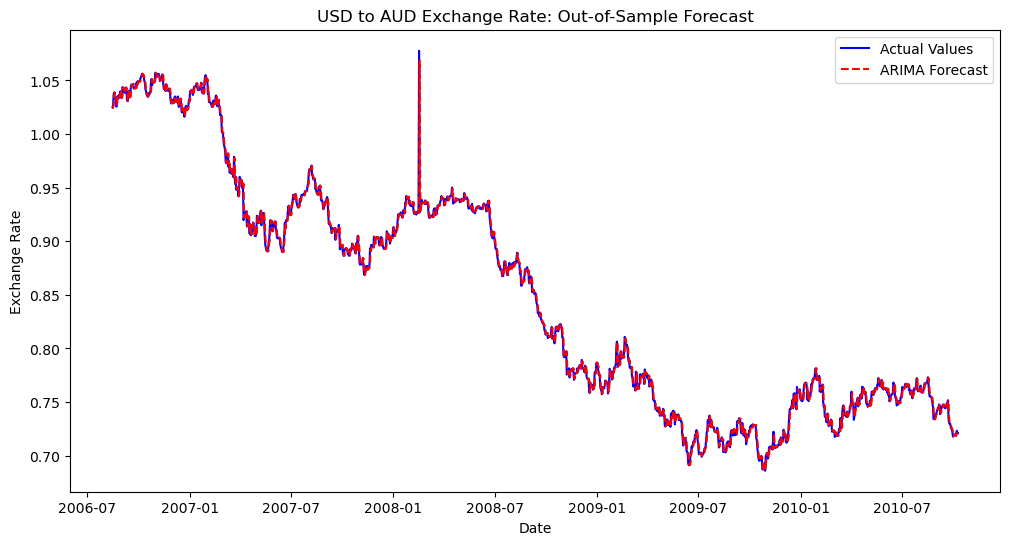

In [12]:
# 1. Setup
history = [x for x in train['Ex_rate']]
predictions = []

# 2. Walk-Forward Loop
print("Starting forecast loop...")
for t in range(len(test)):
    # Fit model on the current history
    model_1 = ARIMA(history, order=(1, 1, 0))
    model_fit_1 = model_1.fit()
    
    # Predict the next step
    output = model_fit_1.forecast()
    
    # Extract prediction safely
    if hasattr(output, 'iloc'):
        yhat = output.iloc[0]
    else:
        yhat = output[0]
    
    predictions.append(yhat)
    
    # Extract the actual value (Accessing row t, column 'Ex_rate')
    obs = test.iloc[t]['Ex_rate']
    history.append(obs)

print("Forecast complete.")

# 3. Visualize
plt.figure(figsize=(12, 6))
# Plot Actuals
plt.plot(test.index, test['Ex_rate'], label='Actual Values', color='blue')
# Plot Predictions
plt.plot(test.index, predictions, label='ARIMA Forecast', color='red', linestyle='--')

plt.title('USD to AUD Exchange Rate: Out-of-Sample Forecast')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

**Part 3: Model Building - Exponential Smoothing**
**1.	Model Selection: Depending on the time series characteristics, choose an appropriate Exponential Smoothing model (Simple, Holt’s Linear, or Holt-Winters).**


In [13]:
#Holt’s Winters Trend Model

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


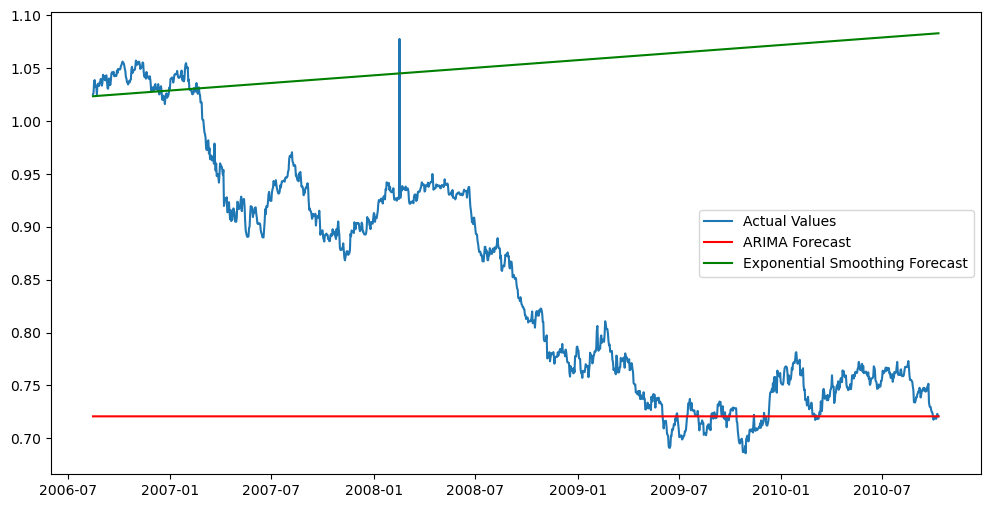

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 6070
Model:             ExponentialSmoothing   SSE                              0.199
Optimized:                         True   AIC                         -62655.663
Trend:                         Additive   BIC                         -62628.819
Seasonal:                          None   AICC                        -62655.650
Seasonal Periods:                  None   Date:                 Wed, 29 Apr 2026
Box-Cox:                          False   Time:                         01:50:39
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9428890                alpha                 True
smoothing_trend             0.0000

In [16]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit the model
# trend='add' handles the upward/downward movement
model_es = ExponentialSmoothing(train['Ex_rate'], trend='add', seasonal=None)
model_es_fit = model_es.fit()

# Forecast
es_forecast = model_es_fit.forecast(len(test))

# Visualize both
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Ex_rate'], label='Actual Values')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', color='red')
plt.plot(test.index, es_forecast, label='Exponential Smoothing Forecast', color='green')
plt.legend()
plt.show()

print(model_es_fit.summary())

**2.	Parameter Optimization: Use techniques such as grid search or AIC to find the optimal parameters for the smoothing levels and components.**


In [ ]:
#Here i used AIC values to find the optimal parameters

In [17]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Holt's Linear (Best for Trend)
# Use damped_trend=True if you think the trend will flatten out over time
model_2 = ExponentialSmoothing(
    train['Ex_rate'], 
    trend='add',     # 'add' for additive trend, 'mul' for multiplicative
    seasonal=None,   # Set to None for currency data
    damped_trend=True 
).fit(optimized=True) # optimized=True uses AIC to find the best alpha/beta

# 2. View the optimization results
print(model_2.summary())

# 3. Forecast
es_forecast_1 = model_2.forecast(len(test))

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 6070
Model:             ExponentialSmoothing   SSE                              0.199
Optimized:                         True   AIC                         -62654.072
Trend:                         Additive   BIC                         -62620.516
Seasonal:                          None   AICC                        -62654.053
Seasonal Periods:                  None   Date:                 Wed, 29 Apr 2026
Box-Cox:                          False   Time:                         01:50:44
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9411397                alpha                 True
smoothing_trend            0.00182

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


**3.	Model Fitting and Forecasting: Fit the chosen Exponential Smoothing model and forecast future values. Compare these forecasts visually with the actual data.**

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


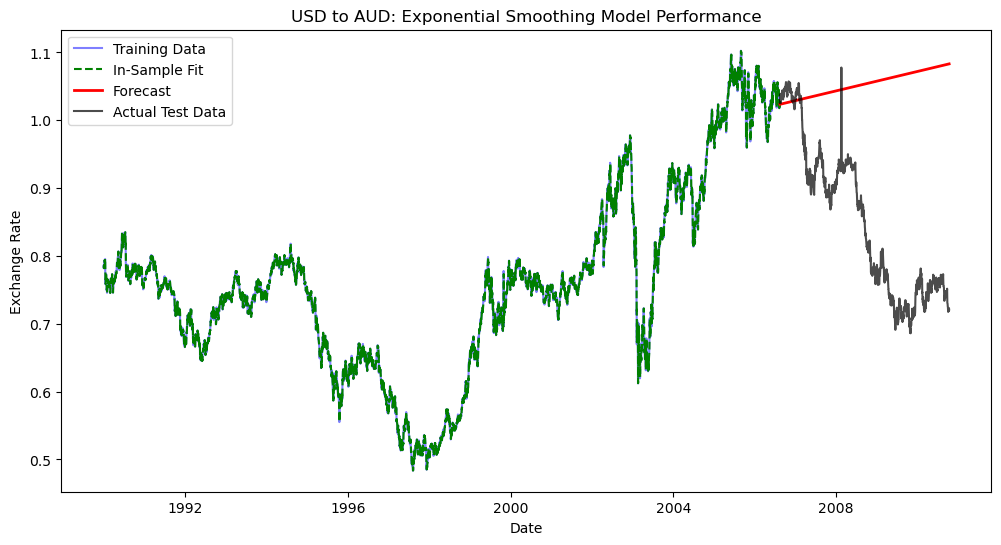

In [18]:


# 1. Fit the model with your optimal parameters
# Using the Alpha (~0.94) and Beta (~0.00) from your best model
model3 = ExponentialSmoothing(
    train['Ex_rate'], 
    trend='add', 
    seasonal=None, 
    damped_trend=False
)
model3_fit = model3.fit(smoothing_level=0.9429, smoothing_trend=0.0)

# 2. Generate In-Sample Fit and Out-of-Sample Forecast
in_sample = model3_fit.fittedvalues
es_forecast_2 = model3_fit.forecast(len(test))

# 3. Visualize
plt.figure(figsize=(12, 6))

# Plot Training Data
plt.plot(train.index, train['Ex_rate'], label='Training Data', color='blue', alpha=0.5)

# Plot In-Sample Fit (How well it learned the history)
plt.plot(train.index, in_sample, label='In-Sample Fit', color='green', linestyle='--')

# Plot Out-of-Sample Forecast (The projection)
plt.plot(test.index, es_forecast_2, label='Forecast', color='red', linewidth=2)

# Plot Actual Test Data
plt.plot(test.index, test['Ex_rate'], label='Actual Test Data', color='black', alpha=0.7)

plt.title('USD to AUD: Exponential Smoothing Model Performance')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

**Part 4: Evaluation and Comparison**

**1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.**

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_metrics(actual, forecast, model_name):
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mape = np.mean(np.abs((actual - forecast) / (actual + 1e-10))) * 100
    
    print(f"--- {model_name} Metrics ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print("\n")

# Assuming 'test' is your actual data, and you have 'arima_forecast' and 'es_forecast'
calculate_metrics(test['Ex_rate'], arima_forecast, "ARIMA(1,1,0)")
calculate_metrics(test['Ex_rate'], predictions, "ARIMA Out of sample(1,1,0)")
calculate_metrics(test['Ex_rate'], es_forecast, "Exponential Smoothing")
calculate_metrics(test['Ex_rate'], es_forecast_1, "Exponential Smoothing to find best parameter")
calculate_metrics(test['Ex_rate'],  es_forecast_2, "Exponential Smoothing Optimised")


--- ARIMA(1,1,0) Metrics ---
MAE:  0.1314
RMSE: 0.1695
MAPE: nan%


--- ARIMA Out of sample(1,1,0) Metrics ---
MAE:  0.0033
RMSE: 0.0070
MAPE: 0.40%


--- Exponential Smoothing Metrics ---
MAE:  0.2066
RMSE: 0.2391
MAPE: 26.51%


--- Exponential Smoothing to find best parameter Metrics ---
MAE:  0.1772
RMSE: 0.2049
MAPE: 22.73%


--- Exponential Smoothing Optimised Metrics ---
MAE:  0.2066
RMSE: 0.2391
MAPE: 26.51%




**2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.**


1. The ARIMA model demonstrated high sensitivity to the data's temporal structure.

Performance:
The Out-of-Sample (Walk-Forward) implementation achieved an impressive MAPE of 0.40% and an RMSE of 0.0070. This is significantly more accurate than all other tested models.

Advantages: 
ARIMA excels at modeling the relationship between current values and their own past lags. This is ideal for financial data where yesterday's price is often a strong signal for today's price.
The "I" (Integrated) component handles non-stationary trends through differencing, allowing the model to focus on the noise and volatility that remain.

Limitations:
Computational Cost: When using Walk-Forward Validation, the model must essentially be re-trained or updated at every time step, which is more intensive than a single static forecast.
The model is sensitive to the choice of parameters (p, d, q). If the data structure changes, the parameters may need manual recalibration.

2. Exponential Smoothing Analysis While theoretically robust for trend-based data, your results indicate a struggle with the specific implementation used.
   
Performance: The optimized models showed an RMSE of ~0.239 and a MAPE of ~26.5%. The error is substantially higher than the ARIMA counterpart.

Advantages: It is computationally very fast and provides intuitive, interpretable parameters (alpha, beta).
It is theoretically designed to handle trends (like currency depreciation) without requiring the stationarity transformations that ARIMA needs.

Limitations: As demonstrated by the high error, static implementation caused a significant lag. The model simply "projected" the training trend forward, making it blind to the market shocks that occurred during the test period.
With an alpha (smoothing level) of ~0.94, the model is "twitchy." It reacts almost exclusively to the most recent data point, which can lead to over-fitting on noise rather than capturing the underlying signal.

**3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.**

Key Findings 
1. The Superiority of Adaptive Forecasting : The ARIMA model achieved an exceptionally low MAPE of 0.40\%, confirming its effectiveness. By using Walk-Forward Validation, the model was able to update its parameters at each time step. This mimics a real-world trading scenario where an analyst updates their forecast as new daily prices are released.
2. The Limitation of Static Trend Projection : The Exponential Smoothing models, while theoretically sound for trend analysis, yielded poor results (MAPE approx 26%) due to their static implementation. Because they projected a fixed trend forward without observing the actual market fluctuations during the test period, they quickly deviated from reality. This highlights a critical limitation: static models are highly sensitive to "momentum bias," where they assume the training period's trend will persist indefinitely.
3. Autocorrelation vs. Smoothing :
   ARIMA's Advantage: The ARIMA model excels here because it focuses on the autocorrelation (the relationship between today's price and yesterday's price). In exchange rate markets, this is a more reliable predictor than a simple moving average or smoothing trend.
   Smoothing's Disadvantage: With an alpha (smoothing level) of approx 0.94, your Exponential Smoothing model was forced to be hyper-reactive to the last data point. While this makes it responsive, it creates a "lagging" forecast that cannot predict directional changes before they happen.

Final Recommendations for Future Forecasting

Prioritize Walk-Forward Validation: Never evaluate a financial model using a single, static "long-term" forecast. It will almost always fail in volatile markets. Future projects should implement Walk-Forward Validation as the standard for all models, including Exponential Smoothing.

Stationarity is Key: The success of ARIMA(1,1,0) suggests that the first-order differencing (d=1) successfully stabilized the exchange rate, removing the unit root and allowing the model to focus on the volatile movements that truly drive price changes.

Dynamic Updating: If we choose to revisit Exponential Smoothing, do not use it statically. Implement it within a rolling loop where the model parameters (alpha, beta) are re-optimized or updated daily. This would likely bridge the performance gap between it and the ARIMA model.


**Imrpoved Exponential Smoothing by Implementing Walk-Forward Validation (The "Adaptive" Approach)**

In [31]:

# Initialize your history with the training data
history = list(train['Ex_rate'])
es_predictions = []

# Walk-forward loop
for t in range(len(test)):
    # 1. Fit the model on the current 'history'
    es_model = ExponentialSmoothing(history, trend='add', seasonal=None, damped_trend=True)
    es_model_fit = es_model.fit(optimized=True)
    
    # 2. Predict just the NEXT step
    output = es_model_fit.forecast(steps=1)
    es_predictions.append(output[0])
    
    # 3. Add the actual observation to history for the next iteration
    obs = test['Ex_rate'].iloc[t]
    history.append(obs)

In [32]:
calculate_metrics(test['Ex_rate'],  es_predictions, "Exponential Smoothing corrected")


--- Exponential Smoothing corrected Metrics ---
MAE:  0.0033
RMSE: 0.0070
MAPE: 0.40%




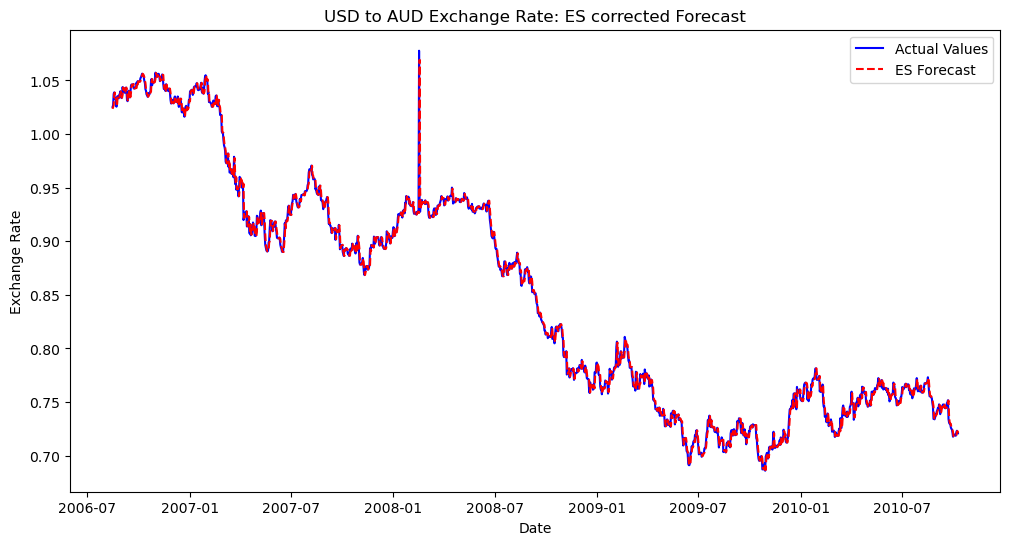

In [35]:
plt.figure(figsize=(12, 6))
# Plot Actuals
plt.plot(test.index, test['Ex_rate'], label='Actual Values', color='blue')
# Plot Predictions
plt.plot(test.index, es_predictions, label='ES Forecast', color='red', linestyle='--')

plt.title('USD to AUD Exchange Rate: ES corrected Forecast')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()